# 🧠 Extracción de Características — CAP Sleep Database

**Notebook 3 del pipeline.** Este cuaderno se ejecuta **después** del notebook
de análisis exploratorio y del notebook de preprocesamiento avanzado, y
**reutiliza** sus salidas:

- Señales **resampleadas a 256 Hz**, escaladas por canal con `StandardScaler` y
  con nombres de canales **normalizados** según `CHANNEL_MAPPING`.
- Pacientes problemáticos (**n13**, **n14**) ya excluidos por saturación total.
- Métricas de sueño y pesos de clase ya calculados.
- Archivos pickle por paciente disponibles en `../data/processed/`.

> Este notebook **no repite** la limpieza ni el EDA. Se enfoca exclusivamente
> en la **extracción de características** sobre ventanas temporales de
> **3 segundos sin traslape**, siguiendo el lineamiento de la referencia
> metodológica adaptada a señales EEG y de sueño.

## 1. Introducción

### 1.1 ¿Qué es la extracción de características?

La **extracción de características** (*feature extraction*) consiste en
transformar una señal cruda — en nuestro caso, segmentos de EEG, EMG, EOG y
ECG — en un **vector numérico compacto** que conserve la información
discriminativa relevante para una tarea posterior (clasificación de etapas de
sueño, detección de eventos CAP, identificación de patologías).

Una época de EEG de 3 segundos a 256 Hz son 768 muestras por canal. Si
trabajáramos con 8 canales y 1000 ventanas por paciente tendríamos
$8 \times 768 \times 1000 = 6{,}144{,}000$ valores por paciente, lo que es
inmanejable para un clasificador clásico. La extracción de características
**reduce drásticamente la dimensionalidad** a unas pocas decenas de
descriptores por ventana, conservando lo esencial.

### 1.2 ¿Por qué es importante en señales EEG?

El EEG no es interpretable directamente como serie de tiempo: sus patrones
clínicamente relevantes (husos del sueño, complejos K, ondas delta, actividad
alfa posterior, ondas theta del sueño REM) viven en el **dominio frecuencial**
y en propiedades estadísticas de segundo orden. La AASM define las etapas de
sueño precisamente a partir de la **proporción de potencia** en bandas
específicas, no de la forma de onda en bruto. Por eso las características
clásicas para EEG combinan tres familias:

1. **Estadísticas temporales** — media, varianza, asimetría, curtosis, RMS, ZCR.
2. **Espectrales** — potencia en bandas δ, θ, α, β, γ, frecuencia dominante,
   energía espectral.
3. **No lineales / de complejidad** — parámetros de Hjorth, entropía de Shannon,
   entropía espectral.

### 1.3 ¿Qué es una ventana temporal? ¿Por qué 3 segundos?

Una **ventana temporal** es un segmento contiguo de la señal sobre el que se
calculan los descriptores. La elección del tamaño es un compromiso:

| Ventana | Pros | Contras |
|---------|------|---------|
| Muy corta (≤1 s) | Buena resolución temporal | Pobre resolución espectral; ruido alto |
| **3 s** | **Captura ≥3 ciclos de delta (0.5–4 Hz); resolución de 0.33 Hz** | Compromiso aceptable |
| 30 s (AASM) | Estándar clínico para estadificación | No detecta eventos cortos como CAP A1 |

**3 segundos** es razonable para EEG porque:

- A 256 Hz, una ventana de 3 s contiene 768 muestras → suficiente para una FFT
  estable con resolución frecuencial $\Delta f = 1/3 \approx 0.33$ Hz.
- Cubre **al menos un ciclo** de la banda delta (0.5 Hz → 2 s por ciclo).
- Es **lo bastante corta** para detectar transiciones rápidas como las fases A
  del CAP (típicamente 2–10 s).

### 1.4 ¿Qué significa "sin traslape"?

Las ventanas se generan de forma **contigua y disjunta**: la ventana $i+1$
comienza exactamente donde termina la ventana $i$. Sin traslape:

- Cada muestra contribuye a una sola ventana → no hay **autocorrelación
  artificial** entre características de ventanas vecinas.
- Es preferible cuando el dataset se usará para **entrenar modelos
  supervisados** (evita fugas de información entre train/test).
- Es más rápido y produce menos datos que ventanas solapadas, lo que reduce
  redundancia y tiempo de cómputo.

### 1.5 Cálculo del tamaño de ventana

$$\text{tamaño\_ventana} = f_s \times \text{duración} = 256 \text{ Hz} \times 3 \text{ s} = 768 \text{ muestras}$$

Como las señales ya fueron **resampleadas a 256 Hz** en el notebook anterior,
**todas las ventanas tienen exactamente 768 muestras**, lo que homogeneiza el
cálculo de FFT y permite vectorización eficiente.

## 2. Importaciones y configuración global

Las librerías se agrupan por finalidad:

- **`mne`** — solo por compatibilidad (no leemos EDF aquí).
- **`numpy`, `scipy`** — operaciones numéricas, FFT, Welch PSD, estadísticas.
- **`pandas`** — DataFrame final de características.
- **`matplotlib`, `seaborn`** — visualizaciones.
- **`sklearn.preprocessing`** — escaladores para comparar normalizaciones.
- **`scipy.stats`** — skewness, kurtosis, entropía.

In [1]:
import os
import re
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal as scipy_signal
from scipy import stats as scipy_stats
from scipy.fft import rfft, rfftfreq

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

warnings.filterwarnings('ignore')

# Compatibilidad NumPy: trapezoid (>=2.0) vs trapz (<2.0)
_trapz = getattr(np, 'trapezoid', None) or np.trapz

# Estilo gráfico consistente con los notebooks anteriores
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})
sns.set_style('whitegrid')

# ── Rutas (mismas que en el notebook de preprocesamiento) ──
BASE_PATH      = Path.cwd() / '../data/cap-sleep-database'
PROCESSED_DIR  = BASE_PATH.parent / 'processed'
FEATURES_DIR   = BASE_PATH.parent / 'features'
FEATURES_DIR.mkdir(exist_ok=True)

# ── Parámetros del pipeline ──
TARGET_SFREQ      = 256       # Hz (heredado del preprocesamiento)
WINDOW_SECONDS    = 3         # duración de cada ventana
WINDOW_SAMPLES    = TARGET_SFREQ * WINDOW_SECONDS   # 768 muestras

# Bandas EEG estándar (AASM / convención clínica)
EEG_BANDS = {
    'delta': (0.5, 4.0),
    'theta': (4.0, 8.0),
    'alpha': (8.0, 13.0),
    'beta':  (13.0, 30.0),
    'gamma': (30.0, 45.0),
}

print(f'Frecuencia de muestreo (heredada) : {TARGET_SFREQ} Hz')
print(f'Duración de ventana                : {WINDOW_SECONDS} s')
print(f'Muestras por ventana               : {WINDOW_SAMPLES}')
print(f'Resolución frecuencial (FFT)       : {TARGET_SFREQ / WINDOW_SAMPLES:.4f} Hz')
print(f'Carpeta de pickles preprocesados   : {PROCESSED_DIR.resolve()}')
print(f'Carpeta de salida de características: {FEATURES_DIR.resolve()}')

Frecuencia de muestreo (heredada) : 256 Hz
Duración de ventana                : 3 s
Muestras por ventana               : 768
Resolución frecuencial (FFT)       : 0.3333 Hz
Carpeta de pickles preprocesados   : D:\Repos\RAHBFDP-2026\data\processed
Carpeta de salida de características: D:\Repos\RAHBFDP-2026\data\features


## 3. Carga de datos preprocesados

### Reutilización del notebook anterior

El notebook de preprocesamiento dejó en `../data/processed/` un pickle por
cada paciente procesado con la estructura:

```python
{
    'patient':       str,            # identificador, ej. 'brux1'
    'disorder':      str,            # categoría diagnóstica
    'data':          np.ndarray,     # (n_canales, n_muestras), µV escalados (z-score)
    'ch_names':      list[str],      # nombres normalizados
    'ch_categories': list[str],      # EEG | EMG | ECG | EOG
    'sfreq':         int,            # 256
}
```

### Transformaciones ya aplicadas (no repetimos aquí)

| Etapa | Aplicada en | Efecto |
|-------|-------------|--------|
| Exclusión n13, n14 | Notebook 2 | Elimina pacientes con saturación 100% |
| Resampleo a 256 Hz | Notebook 2 | Homogeneiza la cohorte (era 100–512 Hz) |
| Normalización de canales | Notebook 2 | Unifica `C3A2` ↔ `C3-A2` ↔ `C3` |
| Selección por categoría | Notebook 2 | Conserva solo EEG/EMG/ECG/EOG |
| StandardScaler por canal | Notebook 2 | Media 0, desviación 1 por canal |

> **Por qué esto facilita la extracción de características:** las amplitudes
> ya están en una escala comparable, los nombres de canal son consistentes
> entre pacientes y la frecuencia de muestreo es única → la FFT, las bandas
> espectrales y los descriptores temporales son **directamente comparables
> entre pacientes**, lo que no ocurría con los datos crudos.

Cargamos como mínimo `brux1`, `ins1` y `narco1` (los tres trastornos
requeridos), añadiendo los demás disponibles para enriquecer la cohorte.

In [2]:
PACIENTES_OBJETIVO = ['brux1', 'ins1', 'narco1', 'nfle1', 'plm1', 'rbd1', 'sdb1', 'n1']

def cargar_paciente_preprocesado(patient, processed_dir=PROCESSED_DIR):
    '''Carga el pickle generado por el notebook de preprocesamiento.'''
    pkl_path = processed_dir / f'{patient}_preprocessed.pkl'
    if not pkl_path.exists():
        return None
    with open(pkl_path, 'rb') as f:
        return pickle.load(f)


pacientes_cargados = {}
for paciente in PACIENTES_OBJETIVO:
    datos = cargar_paciente_preprocesado(paciente)
    if datos is None:
        print(f'  ⚠️  {paciente}: pickle no encontrado, se omite')
        continue
    pacientes_cargados[paciente] = datos

print(f'\\nPacientes disponibles: {len(pacientes_cargados)}')
print(f'{"Paciente":<10} {"Trastorno":<28} {"Canales":>8} {"Muestras":>12} {"Duración":>10}')
print('-' * 72)
for p, d in pacientes_cargados.items():
    dur_min = d['data'].shape[1] / d['sfreq'] / 60
    print(f'{p:<10} {d["disorder"]:<28} {len(d["ch_names"]):>8} '
          f'{d["data"].shape[1]:>12,} {dur_min:>8.1f} min')

\nPacientes disponibles: 8
Paciente   Trastorno                     Canales     Muestras   Duración
------------------------------------------------------------------------
brux1      Bruxismo                           16    3,671,296    239.0 min
ins1       Insomnio                            8   12,288,000    800.0 min
narco1     Narcolepsia                         8    8,663,040    564.0 min
nfle1      Epilepsia nocturna frontal         16    8,355,840    544.0 min
plm1       Movimientos periódicos             12   10,106,880    658.0 min
rbd1       Trastorno REM                      10    7,749,376    504.5 min
sdb1       Trastorno respiratorio              8    7,234,560    471.0 min
n1         Normal                             10    8,862,720    577.0 min


## 4. Información de muestreo y ventanas resultantes

Verificamos que **todos** los pacientes están a 256 Hz (sanity check del
preprocesamiento) y calculamos el número de ventanas de 3 s sin traslape que
producirá cada uno.

$$N_{\text{ventanas}} = \left\lfloor \frac{N_{\text{muestras}}}{f_s \cdot 3} \right\rfloor$$

In [3]:
info_muestreo = []
for p, d in pacientes_cargados.items():
    n_samples = d['data'].shape[1]
    n_windows = n_samples // WINDOW_SAMPLES
    n_eeg = sum(1 for c in d['ch_categories'] if c == 'EEG')
    info_muestreo.append({
        'paciente': p,
        'trastorno': d['disorder'],
        'sfreq_hz': d['sfreq'],
        'n_canales_total': len(d['ch_names']),
        'n_canales_EEG': n_eeg,
        'muestras': n_samples,
        'duracion_min': round(n_samples / d['sfreq'] / 60, 1),
        'ventanas_3s': n_windows,
        'ventanas_eeg_totales': n_windows * n_eeg,
    })

info_muestreo_df = pd.DataFrame(info_muestreo)
print(info_muestreo_df.to_string(index=False))

# Verificación crítica: todos deben estar a 256 Hz
assert info_muestreo_df['sfreq_hz'].nunique() == 1, 'Inconsistencia en sfreq'
assert info_muestreo_df['sfreq_hz'].iloc[0] == TARGET_SFREQ, 'sfreq != 256 Hz'
print(f'\\n✅ Todos los pacientes a {TARGET_SFREQ} Hz')
print(f'✅ Total de ventanas EEG a procesar: '
      f'{info_muestreo_df["ventanas_eeg_totales"].sum():,}')

paciente                  trastorno  sfreq_hz  n_canales_total  n_canales_EEG  muestras  duracion_min  ventanas_3s  ventanas_eeg_totales
   brux1                   Bruxismo       256               16             13   3671296         239.0         4780                 62140
    ins1                   Insomnio       256                8              5  12288000         800.0        16000                 80000
  narco1                Narcolepsia       256                8              5   8663040         564.0        11280                 56400
   nfle1 Epilepsia nocturna frontal       256               16             13   8355840         544.0        10880                141440
    plm1     Movimientos periódicos       256               12              9  10106880         658.0        13160                118440
    rbd1              Trastorno REM       256               10              7   7749376         504.5        10090                 70630
    sdb1     Trastorno respiratorio      

## 5. Segmentación en ventanas

### Función reutilizable

`segmentar_senal` recibe un arreglo 1-D (un canal) y devuelve una matriz
$(N_{\text{ventanas}}, \text{tamaño}_{\text{ventana}})$ donde cada fila es una
ventana contigua y disjunta. El comportamiento clave:

- **Ventanas incompletas se descartan.** La última ventana solo se conserva si
  tiene exactamente `WINDOW_SAMPLES` muestras. Esto evita introducir vectores
  de características con valores poco confiables debido a una FFT con padding.
- **Vectorizado con `reshape`** — mucho más rápido que un bucle Python.
- **No hace copias** cuando la longitud es exacta — usa la vista de memoria.

### Impacto del tamaño de ventana

| Aspecto | Ventana corta (1 s) | **3 s** | Ventana larga (30 s) |
|---|---|---|---|
| Resolución espectral | 1 Hz | **0.33 Hz** | 0.033 Hz |
| Estabilidad estadística | Baja | **Media** | Alta |
| Promediado entre estados | Mínimo | **Aceptable** | Mezcla etapas |
| Coste computacional | Alto (más ventanas) | **Medio** | Bajo |

In [4]:
def segmentar_senal(senal, tamano_ventana=WINDOW_SAMPLES):
    '''
    Segmenta una señal 1-D en ventanas contiguas SIN traslape.

    Parameters
    ----------
    senal : np.ndarray
        Arreglo 1-D con la señal del canal.
    tamano_ventana : int
        Número de muestras por ventana (default 768 = 3 s a 256 Hz).

    Returns
    -------
    np.ndarray, shape (n_ventanas, tamano_ventana)
        Cada fila es una ventana. Las muestras sobrantes (< tamano_ventana)
        se descartan.
    '''
    senal = np.asarray(senal).ravel()
    n_ventanas = len(senal) // tamano_ventana
    if n_ventanas == 0:
        return np.empty((0, tamano_ventana))
    # Recortar a múltiplo exacto y rehacer la forma
    senal_truncada = senal[: n_ventanas * tamano_ventana]
    return senal_truncada.reshape(n_ventanas, tamano_ventana)


# ── Demostración con un canal EEG de brux1 ──
demo_patient = 'brux1' if 'brux1' in pacientes_cargados else next(iter(pacientes_cargados))
demo_data = pacientes_cargados[demo_patient]

# Encontrar el primer canal EEG
demo_eeg_idx = next(
    (i for i, cat in enumerate(demo_data['ch_categories']) if cat == 'EEG'),
    0,
)
demo_signal = demo_data['data'][demo_eeg_idx]
demo_ch_name = demo_data['ch_names'][demo_eeg_idx]

ventanas = segmentar_senal(demo_signal)
print(f'Paciente demo        : {demo_patient}')
print(f'Canal EEG            : {demo_ch_name}')
print(f'Muestras totales     : {len(demo_signal):,}')
print(f'Tamaño de ventana    : {WINDOW_SAMPLES} (= {WINDOW_SECONDS} s × {TARGET_SFREQ} Hz)')
print(f'Ventanas generadas   : {ventanas.shape[0]:,}')
print(f'Muestras descartadas : {len(demo_signal) - ventanas.shape[0] * WINDOW_SAMPLES}')
print(f'Shape resultante     : {ventanas.shape}')

Paciente demo        : brux1
Canal EEG            : Fp2-F4
Muestras totales     : 3,671,296
Tamaño de ventana    : 768 (= 3 s × 256 Hz)
Ventanas generadas   : 4,780
Muestras descartadas : 256
Shape resultante     : (4780, 768)


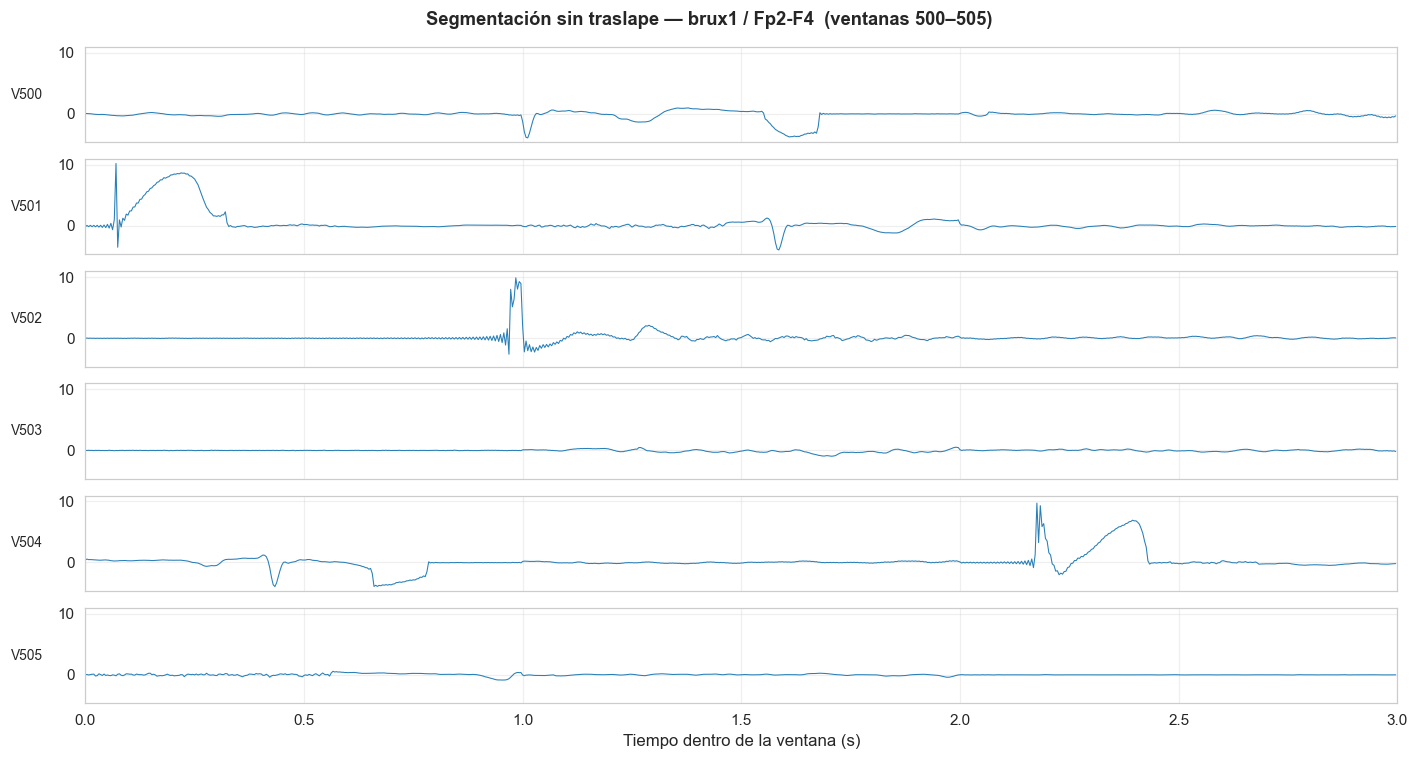

Cada panel es una ventana de 3 s contigua a la anterior. No comparten muestras.


In [5]:
# ── Visualización: 6 ventanas consecutivas ──
fig, axes = plt.subplots(6, 1, figsize=(13, 7), sharey=True)
n_demo = 6
inicio_demo = 500  # arrancar lejos del comienzo para ver actividad de sueño

t = np.arange(WINDOW_SAMPLES) / TARGET_SFREQ
for k in range(n_demo):
    idx = inicio_demo + k
    ax = axes[k]
    ax.plot(t, ventanas[idx], color='#2980B9', linewidth=0.7)
    ax.set_ylabel(f'V{idx}', rotation=0, labelpad=20, va='center', fontsize=9)
    ax.set_xlim(0, WINDOW_SECONDS)
    ax.grid(True, alpha=0.3)
    if k < n_demo - 1:
        ax.set_xticklabels([])
axes[-1].set_xlabel('Tiempo dentro de la ventana (s)')
plt.suptitle(
    f'Segmentación sin traslape — {demo_patient} / {demo_ch_name}  '
    f'(ventanas {inicio_demo}–{inicio_demo + n_demo - 1})',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

print('Cada panel es una ventana de 3 s contigua a la anterior. No comparten muestras.')

## 6. Extracción de características

Extraemos cuatro familias de descriptores por ventana, todas relevantes para
EEG y sueño.

### 6.1 Características en el dominio del tiempo

Resumen estadístico de la forma de onda dentro de la ventana. Son baratas de
calcular y aportan información complementaria a la espectral.

Sea $x = [x_1, x_2, \ldots, x_N]$ la señal de una ventana ($N = 768$):

| Característica | Fórmula | Interpretación fisiológica |
|----------------|---------|----------------------------|
| Media | $\mu = \frac{1}{N}\sum x_i$ | Nivel DC residual; debería ser ≈0 tras escalado |
| Mediana | percentil 50 | Tendencia central robusta a outliers |
| Desv. estándar | $\sigma = \sqrt{\frac{1}{N}\sum(x_i - \mu)^2}$ | Variabilidad de la señal |
| Varianza | $\sigma^2$ | Energía relativa a la media |
| RMS | $\sqrt{\frac{1}{N}\sum x_i^2}$ | Magnitud efectiva (insensible al signo) |
| Energía | $\sum x_i^2$ | Energía total (proporcional a varianza si media=0) |
| Mín / Máx / Rango | $\min$, $\max$, $\max-\min$ | Picos y rango dinámico |
| Skewness | $\frac{E[(x-\mu)^3]}{\sigma^3}$ | Asimetría — útil en husos/complejos K |
| Kurtosis | $\frac{E[(x-\mu)^4]}{\sigma^4} - 3$ | Pesadez de colas — picos agudos vs ondas suaves |
| Zero-crossing rate (ZCR) | $\frac{1}{N-1}\sum \mathbb{1}[\text{sgn}(x_i)\neq \text{sgn}(x_{i+1})]$ | Frecuencia "media" de la señal — útil para EMG |

In [6]:
def extract_time_features(ventana):
    '''
    Calcula 12 características estadísticas en el dominio del tiempo.

    Parameters
    ----------
    ventana : np.ndarray, shape (N,)
        Una ventana de la señal (N = 768 muestras a 256 Hz × 3 s).

    Returns
    -------
    dict
        Diccionario con los 12 descriptores temporales.
    '''
    x = np.asarray(ventana, dtype=float).ravel()
    if x.size == 0 or np.all(np.isnan(x)):
        return {k: np.nan for k in (
            'media', 'mediana', 'std', 'varianza', 'rms', 'energia',
            'maximo', 'minimo', 'rango', 'skewness', 'kurtosis', 'zcr'
        )}

    media   = np.mean(x)
    mediana = np.median(x)
    std     = np.std(x)
    var     = np.var(x)
    rms     = np.sqrt(np.mean(x ** 2))
    energia = np.sum(x ** 2)
    maximo  = np.max(x)
    minimo  = np.min(x)
    rango   = maximo - minimo
    # scipy_stats.skew/kurtosis manejan std=0 devolviendo 0
    skew    = scipy_stats.skew(x) if std > 0 else 0.0
    kurt    = scipy_stats.kurtosis(x) if std > 0 else 0.0
    # ZCR: proporción de cambios de signo entre muestras consecutivas
    zcr     = np.mean(np.diff(np.sign(x)) != 0)

    return {
        'media':    media,
        'mediana':  mediana,
        'std':      std,
        'varianza': var,
        'rms':      rms,
        'energia':  energia,
        'maximo':   maximo,
        'minimo':   minimo,
        'rango':    rango,
        'skewness': skew,
        'kurtosis': kurt,
        'zcr':      zcr,
    }


# Prueba rápida sobre una ventana
demo_feats_tiempo = extract_time_features(ventanas[inicio_demo])
print('Características temporales (ventana de demostración):')
for k, v in demo_feats_tiempo.items():
    print(f'  {k:<10} {v: 12.5f}')

Características temporales (ventana de demostración):
  media          -0.16831
  mediana        -0.04251
  std             0.73920
  varianza        0.54642
  rms             0.75812
  energia       441.40679
  maximo          0.94494
  minimo         -3.95791
  rango           4.90286
  skewness       -3.25439
  kurtosis       11.97601
  zcr             0.06128


### 6.2 Características en el dominio de la frecuencia

#### ¿Qué es la FFT?

La **Transformada Rápida de Fourier (FFT)** descompone una señal temporal en
una suma de senoides de distintas frecuencias. Para una señal real de $N$
muestras a $f_s$ Hz, devuelve los coeficientes complejos en frecuencias
$[0, f_s/2]$ con resolución $\Delta f = f_s / N$.

En nuestra ventana de 768 muestras a 256 Hz:

$$\Delta f = \frac{256}{768} = 0.333 \text{ Hz}$$

#### ¿Qué es la PSD de Welch?

La FFT directa de una sola ventana es ruidosa. **Welch** divide la señal en
subventanas solapadas, calcula la FFT de cada una y **promedia los
periodogramas**, reduciendo varianza al costo de algo de resolución. Es el
método estándar en EEG para estimar la **densidad espectral de potencia (PSD)**.

#### Bandas EEG y su significado fisiológico

| Banda  | Rango (Hz) | Asociación |
|--------|-----------|------------|
| **Delta (δ)** | 0.5–4   | Sueño profundo N3 (ondas lentas) |
| **Theta (θ)** | 4–8     | Sueño ligero N1–N2; somnolencia |
| **Alpha (α)** | 8–13    | Vigilia relajada con ojos cerrados |
| **Beta (β)**  | 13–30   | Vigilia activa, sueño REM (intermitente) |
| **Gamma (γ)** | 30–45   | Procesamiento cognitivo; en sueño suele ser ruido EMG |

La **proporción de potencia** en cada banda es el descriptor más usado para
estadificar sueño automáticamente.

#### Características espectrales extraídas

- **Potencia total** — $\int_{0}^{f_s/2} \text{PSD}(f)\, df$
- **Potencia absoluta por banda** — $\int_{f_1}^{f_2} \text{PSD}(f)\, df$
- **Potencia relativa por banda** — banda / potencia total
- **Frecuencia dominante** — $\arg\max_f \text{PSD}(f)$
- **Frecuencia mediana espectral** — frecuencia que divide la PSD en dos
  mitades de igual potencia (indicador robusto del "centro de gravedad"
  espectral)

In [7]:
def extract_frequency_features(ventana, sfreq=TARGET_SFREQ, bandas=EEG_BANDS):
    '''
    Calcula características espectrales por banda EEG usando PSD de Welch.

    Devuelve potencia total, potencia absoluta y relativa de cada banda,
    frecuencia dominante y frecuencia mediana espectral.
    '''
    x = np.asarray(ventana, dtype=float).ravel()

    # nperseg menor que la ventana → promedia varias subventanas (Welch)
    # Usamos 256 muestras (1 s) para tener ~3 subventanas con 50% de overlap
    nperseg = min(256, len(x))
    f, psd = scipy_signal.welch(
        x, fs=sfreq, nperseg=nperseg, noverlap=nperseg // 2,
        scaling='density',
    )

    df = f[1] - f[0] if len(f) > 1 else 1.0
    pot_total = _trapz(psd, f)

    feats = {'pot_total': pot_total}

    # Potencia por banda (absoluta y relativa)
    for nombre, (f_lo, f_hi) in bandas.items():
        mask = (f >= f_lo) & (f < f_hi)
        if mask.any():
            pot_abs = _trapz(psd[mask], f[mask])
        else:
            pot_abs = 0.0
        feats[f'pot_{nombre}']     = pot_abs
        feats[f'pot_{nombre}_rel'] = pot_abs / pot_total if pot_total > 0 else 0.0

    # Frecuencia dominante
    feats['freq_dominante'] = f[np.argmax(psd)] if len(psd) > 0 else 0.0

    # Frecuencia mediana espectral
    if pot_total > 0:
        psd_cum = np.cumsum(psd) * df
        idx_med = np.searchsorted(psd_cum, pot_total / 2)
        feats['freq_mediana'] = f[min(idx_med, len(f) - 1)]
    else:
        feats['freq_mediana'] = 0.0

    return feats


# Prueba sobre la misma ventana
demo_feats_freq = extract_frequency_features(ventanas[inicio_demo])
print('Características espectrales (ventana de demostración):')
for k, v in demo_feats_freq.items():
    print(f'  {k:<22} {v: 12.6f}')

Características espectrales (ventana de demostración):
  pot_total                  0.660500
  pot_delta                  0.265200
  pot_delta_rel              0.401514
  pot_theta                  0.130235
  pot_theta_rel              0.197177
  pot_alpha                  0.031306
  pot_alpha_rel              0.047398
  pot_beta                   0.046987
  pot_beta_rel               0.071138
  pot_gamma                  0.007544
  pot_gamma_rel              0.011422
  freq_dominante             3.000000
  freq_mediana               3.000000


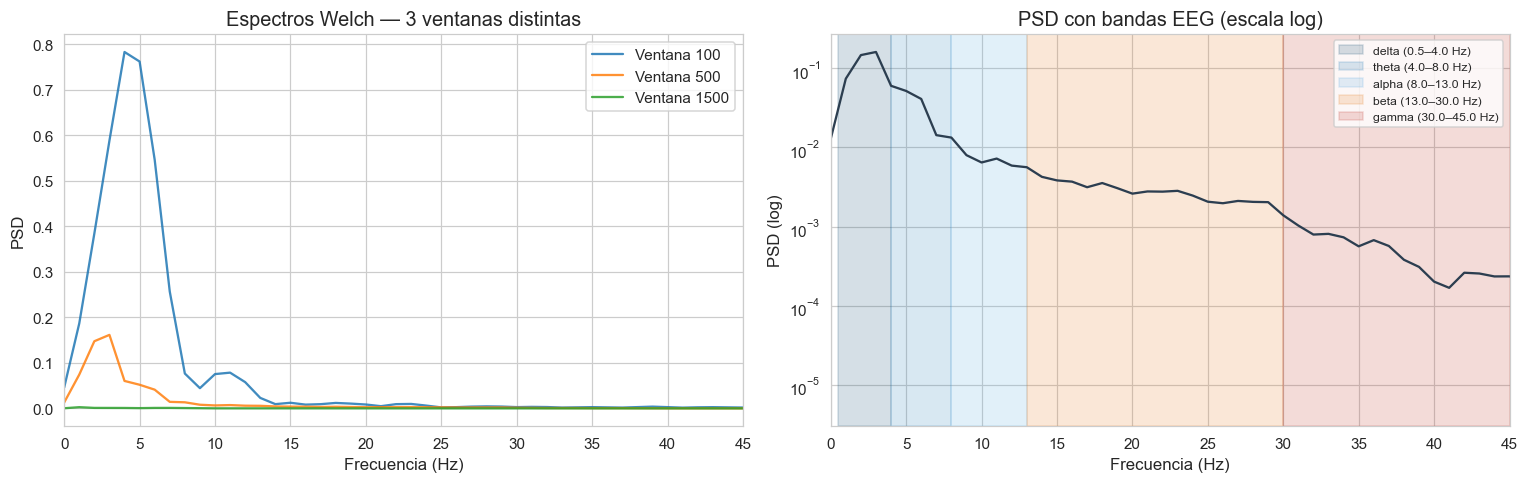

In [8]:
# ── Visualización del espectro Welch para 3 ventanas distintas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel izquierdo: 3 ventanas superpuestas en frecuencia (escala lineal hasta 45 Hz)
ax = axes[0]
for k, idx in enumerate([100, 500, 1500]):
    if idx < len(ventanas):
        f, psd = scipy_signal.welch(
            ventanas[idx], fs=TARGET_SFREQ, nperseg=256, noverlap=128,
        )
        ax.plot(f, psd, label=f'Ventana {idx}', linewidth=1.5, alpha=0.85)
ax.set_xlim(0, 45)
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('PSD')
ax.set_title('Espectros Welch — 3 ventanas distintas')
ax.legend()

# Panel derecho: zonas de bandas EEG marcadas sobre una sola ventana
ax = axes[1]
f, psd = scipy_signal.welch(ventanas[inicio_demo], fs=TARGET_SFREQ, nperseg=256, noverlap=128)
ax.semilogy(f, psd, color='#2C3E50', linewidth=1.5)
colores = ['#1A5276', '#2980B9', '#5DADE2', '#E67E22', '#C0392B']
for (nombre, (lo, hi)), color in zip(EEG_BANDS.items(), colores):
    ax.axvspan(lo, hi, alpha=0.18, color=color, label=f'{nombre} ({lo}–{hi} Hz)')
ax.set_xlim(0, 45)
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('PSD (log)')
ax.set_title('PSD con bandas EEG (escala log)')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

### 6.3 Parámetros de Hjorth

Tres descriptores propuestos por Bo Hjorth (1970) específicamente para EEG.
Combinan información temporal y espectral con muy bajo coste computacional.

Sea $\sigma^2_x$ la varianza de la señal, $\sigma^2_{x'}$ la de su primera
derivada y $\sigma^2_{x''}$ la de la segunda derivada:

| Parámetro | Fórmula | Interpretación |
|-----------|---------|----------------|
| **Activity** | $\sigma^2_x$ | Potencia de la señal — equivalente a varianza |
| **Mobility** | $\sqrt{\sigma^2_{x'} / \sigma^2_x}$ | Frecuencia media — relacionada con la frecuencia dominante |
| **Complexity** | $\dfrac{\text{Mobility}(x')}{\text{Mobility}(x)}$ | Cuánto se aleja la señal de una senoide pura (=1 para senoide) |

Su utilidad para EEG/sueño:

- **Activity** discrimina ondas delta de gran amplitud (N3) vs vigilia.
- **Mobility** baja en ondas lentas, alta en sueño ligero/vigilia.
- **Complexity** crecedurante REM (señal más impredecible) y baja en N3.

In [9]:
def extract_hjorth_parameters(ventana):
    '''
    Calcula los tres parámetros de Hjorth: activity, mobility, complexity.
    '''
    x = np.asarray(ventana, dtype=float).ravel()
    dx = np.diff(x)
    ddx = np.diff(dx)

    var_x   = np.var(x)
    var_dx  = np.var(dx)
    var_ddx = np.var(ddx)

    activity = var_x
    mobility = np.sqrt(var_dx / var_x) if var_x > 0 else 0.0
    mob_dx   = np.sqrt(var_ddx / var_dx) if var_dx > 0 else 0.0
    complexity = mob_dx / mobility if mobility > 0 else 0.0

    return {
        'hjorth_activity':   activity,
        'hjorth_mobility':   mobility,
        'hjorth_complexity': complexity,
    }


demo_feats_hjorth = extract_hjorth_parameters(ventanas[inicio_demo])
print('Parámetros de Hjorth (ventana de demostración):')
for k, v in demo_feats_hjorth.items():
    print(f'  {k:<22} {v: 12.6f}')

Parámetros de Hjorth (ventana de demostración):
  hjorth_activity            0.546421
  hjorth_mobility            0.212667
  hjorth_complexity          4.734786


### 6.4 Entropía

La **entropía de Shannon** mide la "impredecibilidad" o complejidad de la
señal: una señal periódica tiene baja entropía; una señal cercana al ruido
blanco tiene alta entropía.

Sobre la **distribución de amplitudes** (histograma normalizado de las
muestras de la ventana, $p_i$):

$$H_{\text{Shannon}} = -\sum_i p_i \log_2 p_i$$

Sobre la **PSD normalizada** ($p_f = \text{PSD}(f) / \sum \text{PSD}$):

$$H_{\text{espectral}} = -\sum_f p_f \log_2 p_f$$

La **entropía espectral** es particularmente útil porque distingue señales con
energía concentrada en pocas frecuencias (baja entropía → husos del sueño,
ondas delta puras) de señales con energía repartida (alta entropía → ruido,
artefactos, vigilia activa).

In [10]:
def extract_entropy(ventana, sfreq=TARGET_SFREQ, bins=16):
    '''
    Calcula entropía de Shannon sobre amplitudes y entropía espectral
    sobre la PSD normalizada.
    '''
    x = np.asarray(ventana, dtype=float).ravel()

    # Entropía de Shannon sobre histograma de amplitudes
    hist, _ = np.histogram(x, bins=bins, density=False)
    p = hist[hist > 0] / hist.sum()
    shannon = -np.sum(p * np.log2(p)) if p.size > 0 else 0.0

    # Entropía espectral sobre la PSD normalizada
    nperseg = min(256, len(x))
    _, psd = scipy_signal.welch(x, fs=sfreq, nperseg=nperseg, noverlap=nperseg // 2)
    psd_norm = psd / psd.sum() if psd.sum() > 0 else psd
    psd_norm = psd_norm[psd_norm > 0]
    spectral = -np.sum(psd_norm * np.log2(psd_norm)) if psd_norm.size > 0 else 0.0

    return {
        'entropia_shannon':  shannon,
        'entropia_espectral': spectral,
    }


demo_feats_entropy = extract_entropy(ventanas[inicio_demo])
print('Entropías (ventana de demostración):')
for k, v in demo_feats_entropy.items():
    print(f'  {k:<22} {v: 12.6f}')

Entropías (ventana de demostración):
  entropia_shannon           2.278581
  entropia_espectral         3.575514


## 7. Implementación modular — función maestra

`extract_features_from_window` orquesta las cuatro familias y devuelve un
diccionario plano con **~30 características por ventana**.

Buenas prácticas implementadas:

- **Manejo de errores** — si una ventana es completamente plana o tiene NaNs,
  devuelve un vector con NaN en lugar de fallar.
- **Sin estado compartido** — la función es pura, segura para paralelizar.
- **Diccionario ordenado** — facilita la construcción del DataFrame final.

In [11]:
def extract_features_from_window(ventana, sfreq=TARGET_SFREQ, bandas=EEG_BANDS):
    '''
    Pipeline maestro: extrae características de tiempo, frecuencia, Hjorth
    y entropía de una ventana de señal.

    Returns
    -------
    dict
        ~30 características por ventana.
    '''
    try:
        x = np.asarray(ventana, dtype=float).ravel()
        if x.size == 0 or np.all(np.isnan(x)):
            raise ValueError('Ventana vacía o con NaNs')

        feats = {}
        feats.update(extract_time_features(x))
        feats.update(extract_frequency_features(x, sfreq, bandas))
        feats.update(extract_hjorth_parameters(x))
        feats.update(extract_entropy(x, sfreq))
        return feats

    except Exception as e:
        # En caso de error, devolver un diccionario vacío con NaNs para
        # que el DataFrame final mantenga forma consistente.
        return {k: np.nan for k in [
            'media', 'mediana', 'std', 'varianza', 'rms', 'energia',
            'maximo', 'minimo', 'rango', 'skewness', 'kurtosis', 'zcr',
            'pot_total',
            'pot_delta', 'pot_delta_rel', 'pot_theta', 'pot_theta_rel',
            'pot_alpha', 'pot_alpha_rel', 'pot_beta', 'pot_beta_rel',
            'pot_gamma', 'pot_gamma_rel',
            'freq_dominante', 'freq_mediana',
            'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity',
            'entropia_shannon', 'entropia_espectral',
        ]}


# Prueba completa
feats_completo = extract_features_from_window(ventanas[inicio_demo])
print(f'Total de características por ventana: {len(feats_completo)}')
print('\\nLista completa:')
for i, (k, v) in enumerate(feats_completo.items(), 1):
    print(f'  {i:2d}. {k:<22} {v: 12.6f}')

Total de características por ventana: 30
\nLista completa:
   1. media                     -0.168308
   2. mediana                   -0.042513
   3. std                        0.739203
   4. varianza                   0.546421
   5. rms                        0.758122
   6. energia                  441.406785
   7. maximo                     0.944943
   8. minimo                    -3.957913
   9. rango                      4.902857
  10. skewness                  -3.254387
  11. kurtosis                  11.976005
  12. zcr                        0.061278
  13. pot_total                  0.660500
  14. pot_delta                  0.265200
  15. pot_delta_rel              0.401514
  16. pot_theta                  0.130235
  17. pot_theta_rel              0.197177
  18. pot_alpha                  0.031306
  19. pot_alpha_rel              0.047398
  20. pot_beta                   0.046987
  21. pot_beta_rel               0.071138
  22. pot_gamma                  0.007544
  23. pot_gamma_r

## 8. Generación del dataset de características

Recorremos **todos los pacientes cargados**, todas las **ventanas de 3 s sin
traslape**, y todos los **canales EEG** (que son los más útiles para sueño y
los más consistentes en la cohorte). Para cada combinación generamos una fila
con:

- Identificadores: `patient`, `disorder`, `channel`, `ch_category`,
  `window_idx`, `onset_s`.
- Las ~30 características numéricas.

> **Nota sobre etiquetas de sueño:** el notebook de preprocesamiento generó
> `sleep_metrics.csv` con métricas agregadas, pero las anotaciones de etapa
> por época viven en los `.edf.st` que parsea ese mismo notebook. Si
> existieran las anotaciones a nivel de ventana, las inyectaríamos aquí
> mediante `onset_s`. Como no están persistidas a esa granularidad, dejamos
> el campo `disorder` (etiqueta a nivel de paciente) como variable objetivo
> por defecto.

In [12]:
def construir_dataset_caracteristicas(pacientes_dict, solo_eeg=True):
    '''
    Recorre pacientes → canales → ventanas y extrae características.

    Parameters
    ----------
    pacientes_dict : dict
        Salida de `cargar_paciente_preprocesado` agrupada por paciente.
    solo_eeg : bool
        Si True, se procesan únicamente canales EEG (recomendado).

    Returns
    -------
    pd.DataFrame
        Una fila por (paciente, canal, ventana).
    '''
    filas = []
    for paciente, datos in pacientes_dict.items():
        data    = datos['data']                  # (n_canales, n_muestras)
        sfreq   = datos['sfreq']
        ch_names = datos['ch_names']
        ch_cats  = datos['ch_categories']
        disorder = datos['disorder']

        for ch_idx, (ch_name, ch_cat) in enumerate(zip(ch_names, ch_cats)):
            if solo_eeg and ch_cat != 'EEG':
                continue

            ventanas_ch = segmentar_senal(data[ch_idx], WINDOW_SAMPLES)
            for w_idx, ventana in enumerate(ventanas_ch):
                feats = extract_features_from_window(ventana, sfreq)
                fila = {
                    'patient':     paciente,
                    'disorder':    disorder,
                    'channel':     ch_name,
                    'ch_category': ch_cat,
                    'window_idx':  w_idx,
                    'onset_s':     w_idx * WINDOW_SECONDS,
                }
                fila.update(feats)
                filas.append(fila)

    return pd.DataFrame(filas)


print('Extrayendo características... (puede tardar 1–3 min según número de pacientes)')
features_df = construir_dataset_caracteristicas(pacientes_cargados, solo_eeg=True)

print(f'\\n✅ Dataset construido: {features_df.shape[0]:,} filas × {features_df.shape[1]} columnas')
print(f'\\nPacientes en el dataset : {features_df["patient"].nunique()}')
print(f'Canales únicos          : {features_df["channel"].nunique()}')
print(f'Ventanas por paciente:')
print(features_df.groupby('patient').size().to_string())

Extrayendo características... (puede tardar 1–3 min según número de pacientes)
\n✅ Dataset construido: 656,930 filas × 36 columnas
\nPacientes en el dataset : 8
Canales únicos          : 13
Ventanas por paciente:
patient
brux1      62140
ins1       80000
n1         80780
narco1     56400
nfle1     141440
plm1      118440
rbd1       70630
sdb1       47100


In [13]:
# Vista previa
print('Primeras filas del dataset de características:')
features_df.head(5).round(3)

Primeras filas del dataset de características:


,patient,disorder,channel,ch_category,window_idx,onset_s,media,mediana,std,varianza,...,pot_beta_rel,pot_gamma,pot_gamma_rel,freq_dominante,freq_mediana,hjorth_activity,hjorth_mobility,hjorth_complexity,entropia_shannon,entropia_espectral
0,brux1,Bruxismo,Fp2-F4,EEG,0,0,0.119,0.069,0.894,0.800,...,0.108,0.021,0.023,3.0,3.0,0.800,0.261,3.002,2.728,3.713
1,brux1,Bruxismo,Fp2-F4,EEG,1,3,-0.016,0.019,0.957,0.916,...,0.084,0.017,0.016,3.0,3.0,0.916,0.229,3.537,2.031,3.464
2,brux1,Bruxismo,Fp2-F4,EEG,2,6,0.012,0.017,0.390,0.152,...,0.253,0.004,0.027,3.0,5.0,0.152,0.353,2.646,2.177,4.528
3,brux1,Bruxismo,Fp2-F4,EEG,3,9,-0.256,-0.101,0.524,0.274,...,0.121,0.005,0.032,1.0,2.0,0.274,0.180,4.508,2.925,3.465
4,brux1,Bruxismo,Fp2-F4,EEG,4,12,-0.061,-0.002,0.793,0.629,...,0.443,0.023,0.025,13.0,13.0,0.629,0.373,1.636,0.773,4.914


In [14]:
# Estadísticas resumidas de las características numéricas
cols_num = features_df.select_dtypes(include=[np.number]).columns
cols_feats = [c for c in cols_num if c not in ('window_idx', 'onset_s')]
print(f'Resumen estadístico de las {len(cols_feats)} características:')
features_df[cols_feats].describe().T.round(3)

Resumen estadístico de las 30 características:


,count,mean,std,min,25%,50%,75%,max
media,656930.0,0.000,0.193,-15.070,-0.039,-0.002,0.035,18.796
mediana,656930.0,-0.001,0.218,-21.937,-0.044,-0.003,0.039,19.820
std,656930.0,0.635,0.748,0.000,0.307,0.449,0.718,54.779
varianza,656930.0,0.963,10.356,0.000,0.094,0.202,0.515,3000.749
rms,656930.0,0.643,0.766,0.000,0.310,0.454,0.726,56.058
energia,656930.0,768.006,8419.973,0.000,73.775,158.218,404.622,2413464.547
maximo,656930.0,1.772,2.254,-0.819,0.826,1.223,1.924,133.949
minimo,656930.0,-1.839,2.351,-119.583,-1.974,-1.242,-0.833,2.057
rango,656930.0,3.611,4.379,0.000,1.723,2.499,3.930,239.166
skewness,656930.0,-0.049,0.860,-21.754,-0.285,0.003,0.272,24.424


## 9. Normalización y escalamiento de características

### Diferencia entre escalar la **señal** y escalar las **características**

- En el notebook anterior aplicamos `StandardScaler` a la **señal cruda** por
  canal — eso homogeneiza las amplitudes entre canales y pacientes.
- Aquí escalamos las **características derivadas**, que tienen unidades muy
  distintas (potencia en µV², frecuencias en Hz, entropía en bits,
  coeficientes de forma adimensionales).

Sin este segundo escalado, una característica como `energia` (con valores en
el orden de $10^2$) dominaría a `freq_dominante` (orden de $10^0$) en
cualquier modelo basado en distancias (KNN, SVM, k-means, redes neuronales).

### Comparación de tres escaladores

| Escalador | Fórmula | Cuándo usarlo |
|-----------|---------|---------------|
| **StandardScaler** | $z = (x - \mu) / \sigma$ | Características aproximadamente gaussianas |
| **MinMaxScaler** | $z = (x - \min) / (\max - \min)$ | Cuando se requiere rango fijo [0, 1] (redes neuronales con sigmoides) |
| **RobustScaler** | $z = (x - \text{med}) / \text{IQR}$ | Cuando hay outliers (frecuente en EEG con artefactos residuales) |

In [15]:
caract_cols = [c for c in cols_feats]
X = features_df[caract_cols].values

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
}

X_scaled = {nombre: sc.fit_transform(X) for nombre, sc in scalers.items()}

# Comparación de estadísticas en una característica representativa
ejemplo_col = 'pot_alpha'
idx_ejemplo = caract_cols.index(ejemplo_col)
print(f'Comparación de escaladores sobre la característica "{ejemplo_col}":\\n')
print(f'{"":<18} {"min":>10} {"max":>10} {"media":>10} {"std":>10} {"mediana":>10}')
print('-' * 70)
orig = X[:, idx_ejemplo]
print(f'{"Original":<18} {orig.min():>10.3f} {orig.max():>10.3f} '
      f'{orig.mean():>10.3f} {orig.std():>10.3f} {np.median(orig):>10.3f}')
for nombre, Xs in X_scaled.items():
    v = Xs[:, idx_ejemplo]
    print(f'{nombre:<18} {v.min():>10.3f} {v.max():>10.3f} '
          f'{v.mean():>10.3f} {v.std():>10.3f} {np.median(v):>10.3f}')

Comparación de escaladores sobre la característica "pot_alpha":\n
                          min        max      media        std    mediana
----------------------------------------------------------------------
Original                0.000    128.277      0.033      0.383      0.012
StandardScaler         -0.086    335.129      0.000      1.000     -0.055
MinMaxScaler            0.000      1.000      0.000      0.003      0.000
RobustScaler           -0.616   6695.901      1.106     19.977     -0.000


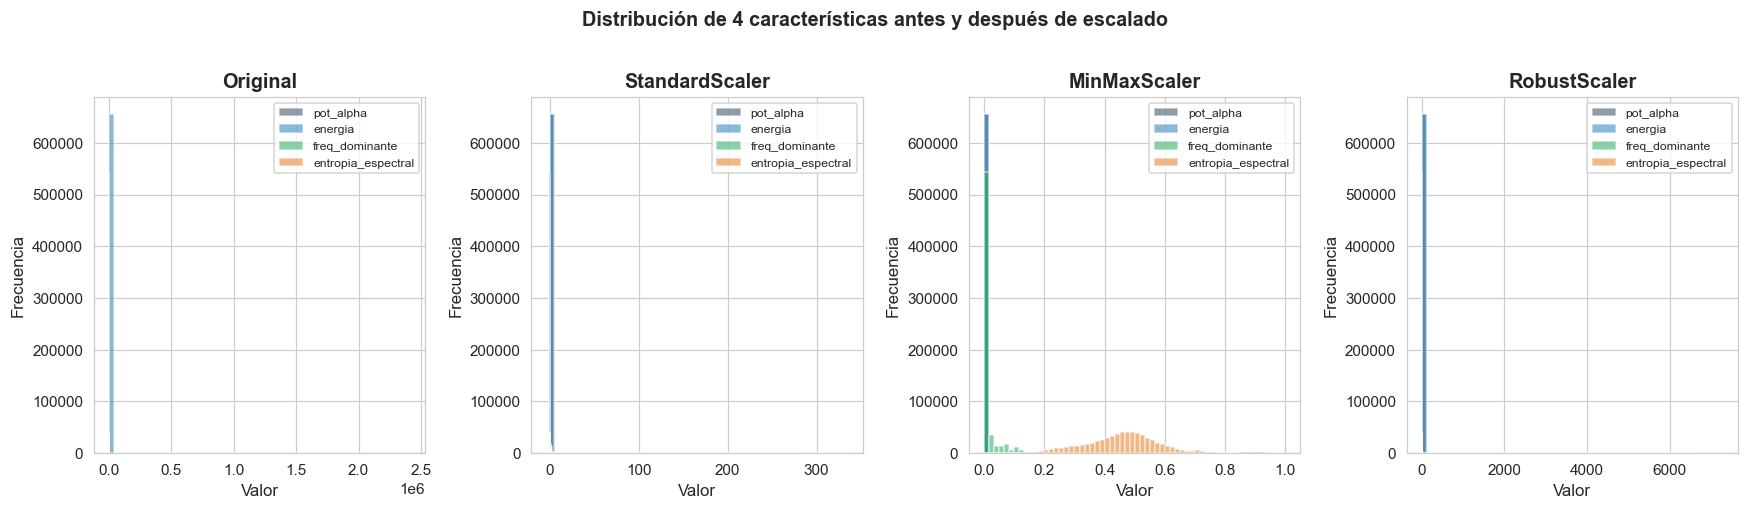

In [16]:
# ── Visualización: antes vs después de cada escalador ──
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
muestras_a_mostrar = ['pot_alpha', 'energia', 'freq_dominante', 'entropia_espectral']

datos_para_plot = {
    'Original': X,
    **X_scaled,
}

colores = ['#34495E', '#2980B9', '#27AE60', '#E67E22']
for ax, (nombre, datos) in zip(axes, datos_para_plot.items()):
    for col, color in zip(muestras_a_mostrar, colores):
        i = caract_cols.index(col)
        ax.hist(datos[:, i], bins=60, alpha=0.55, label=col, color=color)
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de 4 características antes y después de escalado',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Elegimos StandardScaler para el dataset final
# (es lo más natural para características EEG aproximadamente gaussianas)
features_df_scaled = features_df.copy()
features_df_scaled[caract_cols] = X_scaled['StandardScaler']

# Dataset MinMax para uso con redes neuronales / modelos con sigmoides
features_df_minmax = features_df.copy()
features_df_minmax[caract_cols] = X_scaled['MinMaxScaler']

# Dataset Robust para casos con artefactos
features_df_robust = features_df.copy()
features_df_robust[caract_cols] = X_scaled['RobustScaler']

print('Datasets escalados generados:')
print(f'  features_df         (original)        — {features_df.shape}')
print(f'  features_df_scaled  (StandardScaler)  — {features_df_scaled.shape}')
print(f'  features_df_minmax  (MinMaxScaler)    — {features_df_minmax.shape}')
print(f'  features_df_robust  (RobustScaler)    — {features_df_robust.shape}')

Datasets escalados generados:
  features_df         (original)        — (656930, 36)
  features_df_scaled  (StandardScaler)  — (656930, 36)
  features_df_minmax  (MinMaxScaler)    — (656930, 36)
  features_df_robust  (RobustScaler)    — (656930, 36)


## 10. Análisis de balance de clases

A nivel de **paciente** la cohorte CAP es muy desbalanceada (más trastornos
respiratorios y NFLE que insomnio o narcolepsia). A nivel de **ventana**, el
desbalance se amplifica porque los pacientes con grabaciones largas aportan
más ventanas.

### Impacto del desbalance

Modelos entrenados sobre datasets desbalanceados tienden a:

- **Predecir siempre la clase mayoritaria** y aun así alcanzar accuracy alto.
- Tener **recall pésimo** en clases minoritarias (las clínicamente
  interesantes).
- Generar **fronteras de decisión sesgadas** hacia el centroide mayoritario.

### Estrategias disponibles

| Estrategia | Implementación |
|------------|----------------|
| Pesos de clase | Cargados desde `processed/class_weights.csv` (notebook 2) |
| SMOTE | Sintetiza ejemplos minoritarios; ver notebook 2 |
| Submuestreo de mayoritaria | Reduce ejemplos a nivel ventana |
| Métricas por clase | Reportar F1 macro, no accuracy |

In [18]:
class_counts_ventanas = features_df['disorder'].value_counts()
class_counts_pacientes = (
    features_df.groupby('disorder')['patient'].nunique().sort_values(ascending=False)
)

print('Distribución de clases a NIVEL DE VENTANA:')
print(class_counts_ventanas.to_string())
print(f'\\nRatio max/min (ventanas): '
      f'{class_counts_ventanas.max():,} : {class_counts_ventanas.min():,} '
      f'= {class_counts_ventanas.max() / class_counts_ventanas.min():.1f} ×')

print('\\n\\nDistribución de clases a NIVEL DE PACIENTE:')
print(class_counts_pacientes.to_string())

Distribución de clases a NIVEL DE VENTANA:
disorder
Epilepsia nocturna frontal    141440
Movimientos periódicos        118440
Normal                         80780
Insomnio                       80000
Trastorno REM                  70630
Bruxismo                       62140
Narcolepsia                    56400
Trastorno respiratorio         47100
\nRatio max/min (ventanas): 141,440 : 47,100 = 3.0 ×
\n\nDistribución de clases a NIVEL DE PACIENTE:
disorder
Bruxismo                      1
Epilepsia nocturna frontal    1
Insomnio                      1
Movimientos periódicos        1
Narcolepsia                   1
Normal                        1
Trastorno REM                 1
Trastorno respiratorio        1


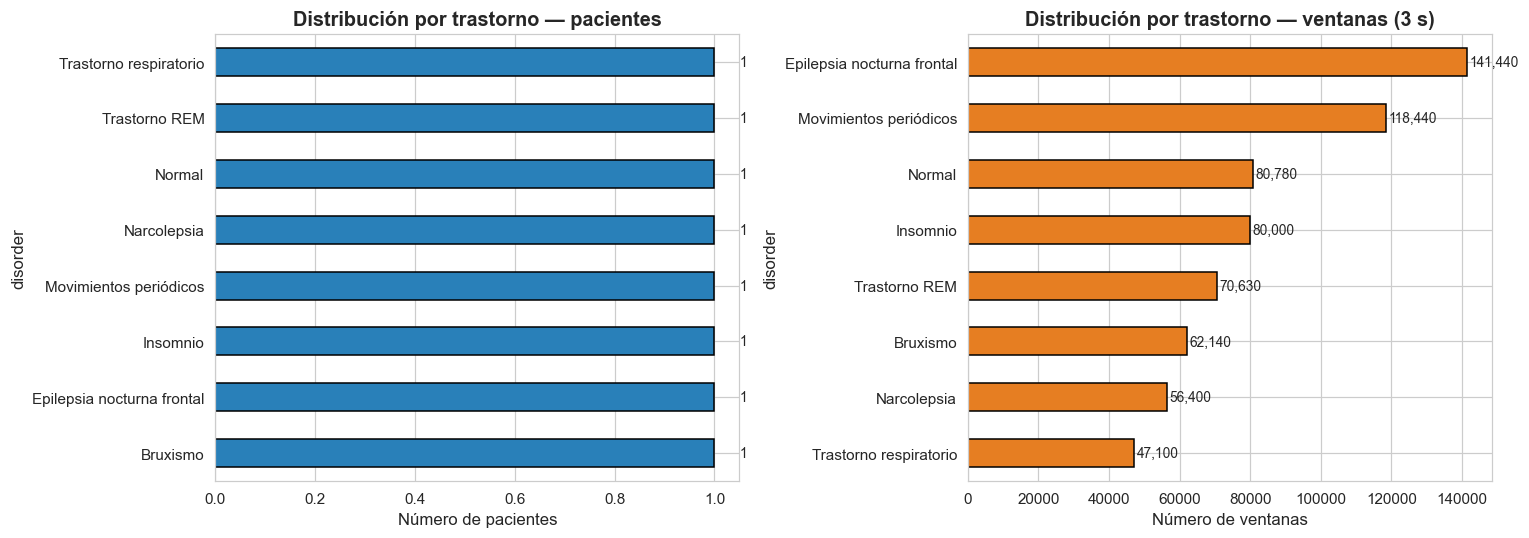

In [19]:
# ── Visualización ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts_pacientes.sort_values().plot(
    kind='barh', ax=axes[0], color='#2980B9', edgecolor='black',
)
axes[0].set_title('Distribución por trastorno — pacientes', fontweight='bold')
axes[0].set_xlabel('Número de pacientes')
for i, v in enumerate(class_counts_pacientes.sort_values()):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=9)

class_counts_ventanas.sort_values().plot(
    kind='barh', ax=axes[1], color='#E67E22', edgecolor='black',
)
axes[1].set_title('Distribución por trastorno — ventanas (3 s)', fontweight='bold')
axes[1].set_xlabel('Número de ventanas')
for i, v in enumerate(class_counts_ventanas.sort_values()):
    axes[1].text(v + max(class_counts_ventanas) * 0.005, i,
                 f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
# Cargar pesos de clase del notebook anterior, si existen
class_weights_path = PROCESSED_DIR / 'class_weights.csv'
if class_weights_path.exists():
    class_weights = pd.read_csv(class_weights_path, index_col=0, header=0).squeeze()
    print('Pesos de clase reutilizados del notebook de preprocesamiento:')
    print(class_weights.to_string())
else:
    print('⚠️  class_weights.csv no encontrado — generar en el notebook 2.')

Pesos de clase reutilizados del notebook de preprocesamiento:
Bruxismo                      6.625000
Epilepsia nocturna frontal    0.331250
Insomnio                      1.472222
Movimientos periódicos        1.325000
Narcolepsia                   2.650000
Normal                        0.946429
Trastorno REM                 0.602273
Trastorno respiratorio        3.312500


## 11. Visualizaciones de las características

Exploramos cómo se distribuyen las características y si separan los
trastornos. Las visualizaciones se construyen sobre el dataset **original**
(no escalado) para que las unidades sigan siendo interpretables.

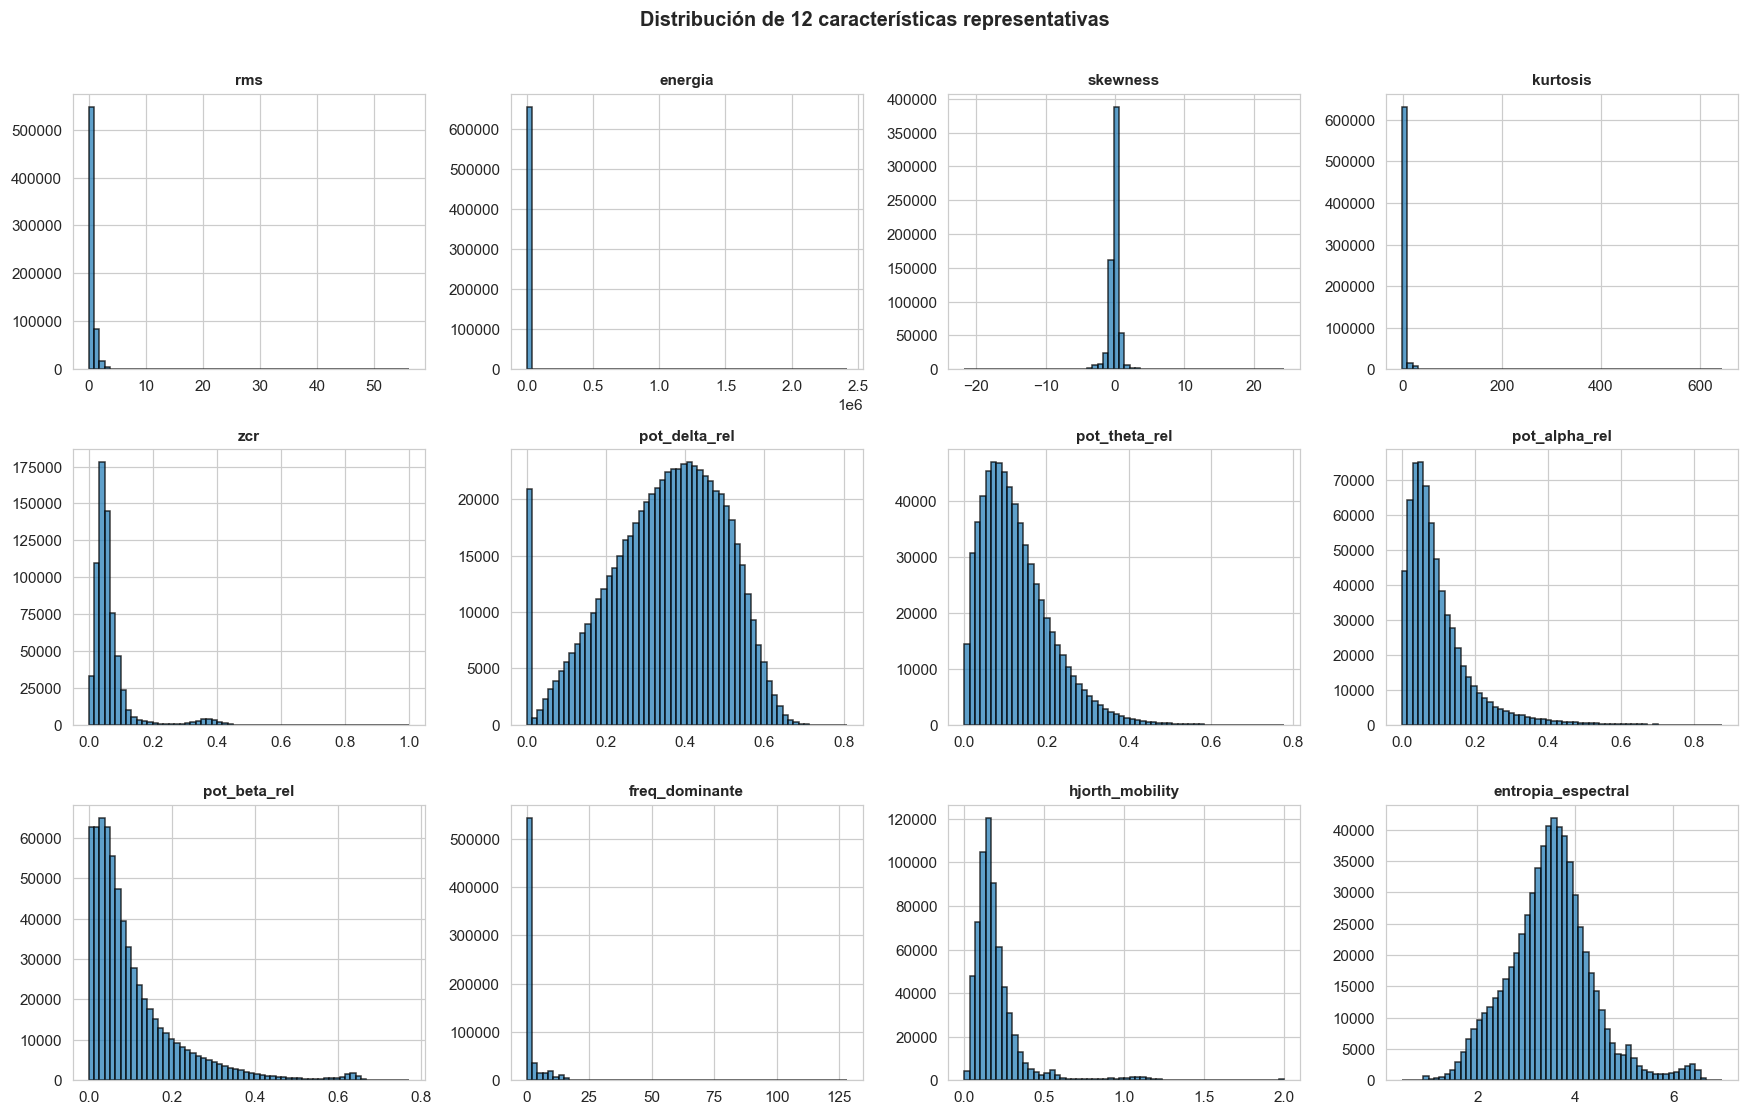

In [21]:
# ── Histogramas de un conjunto representativo de características ──
caract_a_mostrar = [
    'rms', 'energia', 'skewness', 'kurtosis', 'zcr',
    'pot_delta_rel', 'pot_theta_rel', 'pot_alpha_rel', 'pot_beta_rel',
    'freq_dominante', 'hjorth_mobility', 'entropia_espectral',
]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, caract_a_mostrar):
    ax.hist(features_df[col].dropna(), bins=60,
            color='#2980B9', edgecolor='black', alpha=0.75)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Distribución de 12 características representativas',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

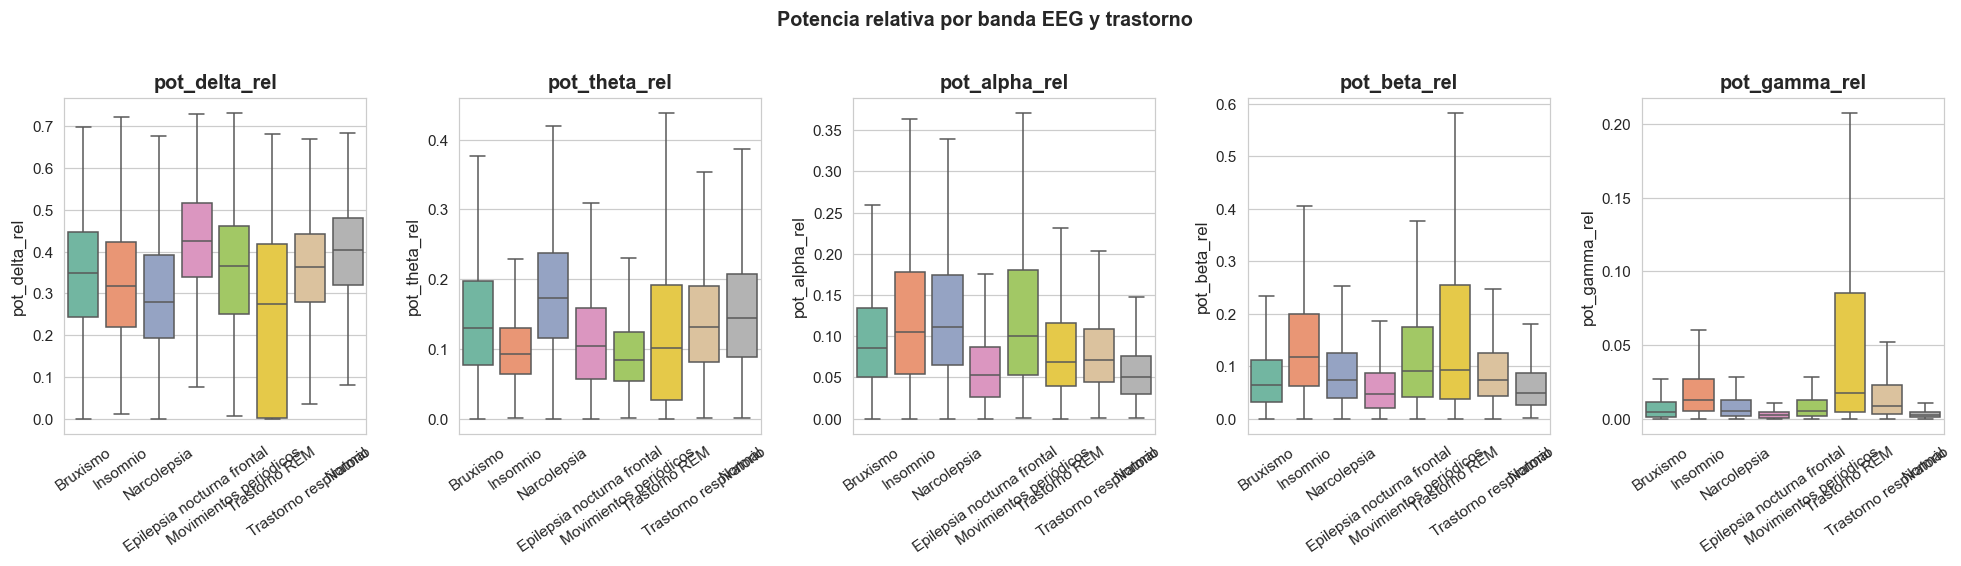

In [22]:
# ── Boxplots por trastorno: potencia relativa por banda ──
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)
bandas_rel = ['pot_delta_rel', 'pot_theta_rel', 'pot_alpha_rel',
              'pot_beta_rel', 'pot_gamma_rel']
for ax, banda in zip(axes, bandas_rel):
    sns.boxplot(
        data=features_df, x='disorder', y=banda, ax=ax,
        palette='Set2', showfliers=False,
    )
    ax.set_title(banda, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
plt.suptitle('Potencia relativa por banda EEG y trastorno',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

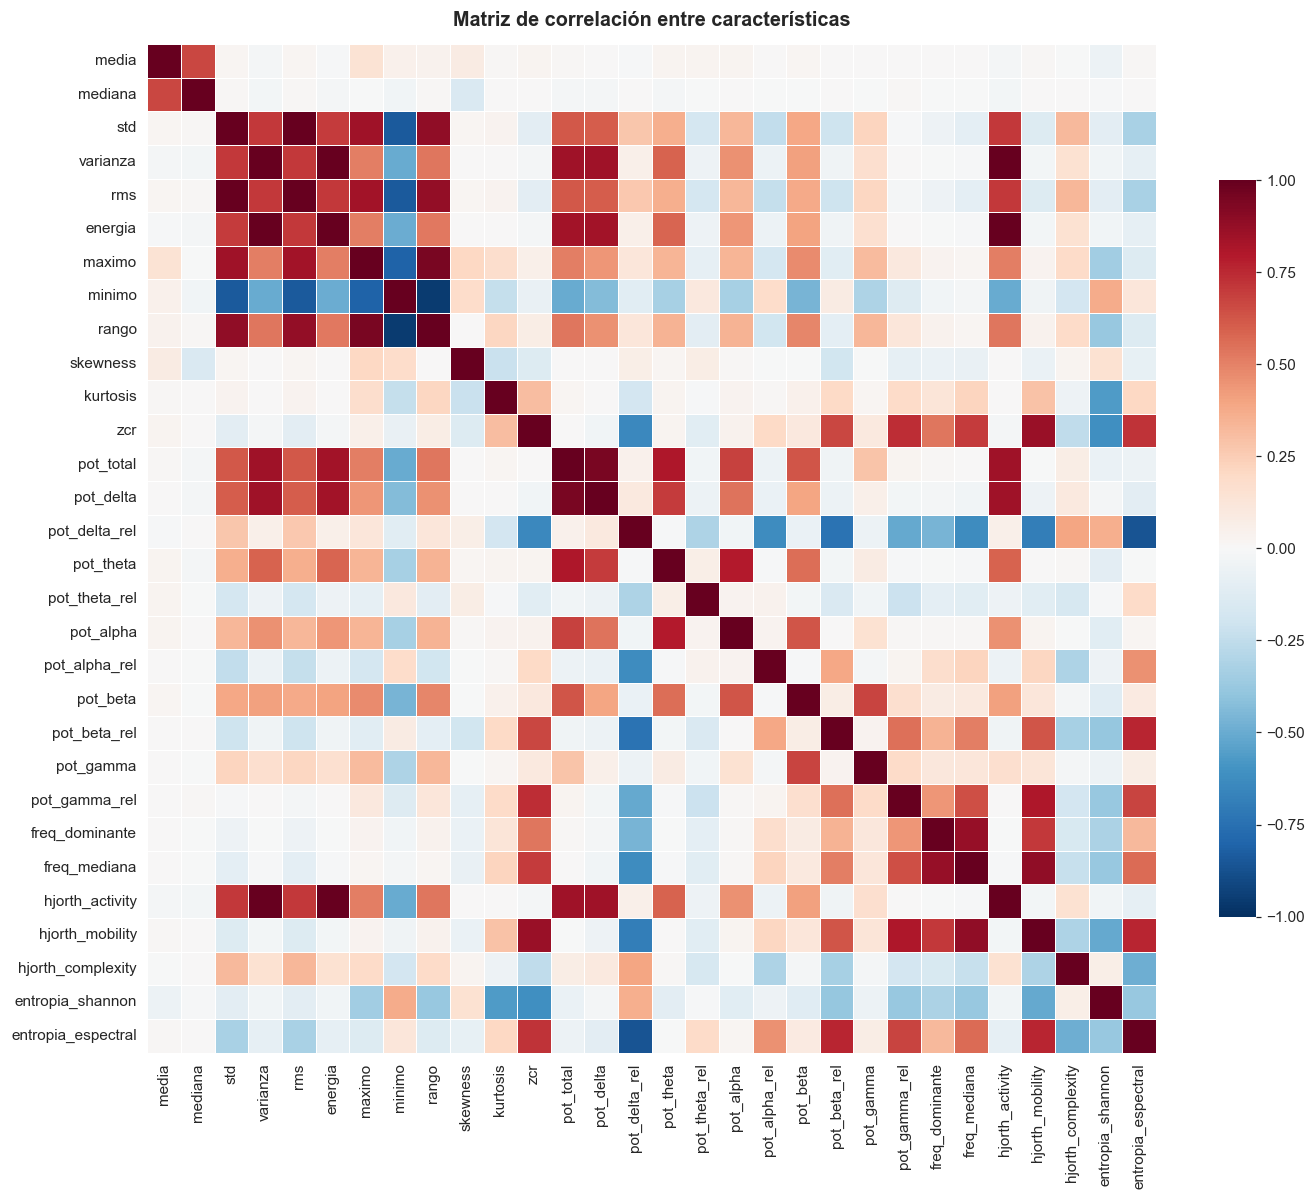

\nPares de características altamente correlacionadas (|r| > 0.9): 7
   feat_1          feat_2         r
 varianza hjorth_activity  1.000000
      std             rms  0.998178
 varianza         energia  0.996509
  energia hjorth_activity  0.996509
   minimo           rango -0.953140
pot_total       pot_delta  0.949454
   maximo           rango  0.948907


In [23]:
# ── Heatmap de correlaciones entre características ──
corr = features_df[caract_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.7},
)
ax.set_title('Matriz de correlación entre características',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Reportar pares con correlación extrema (|r| > 0.9, excluyendo diagonal)
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'feat_1', 'level_1': 'feat_2', 0: 'r'})
)
redundantes = corr_pairs[corr_pairs['r'].abs() > 0.9].sort_values('r', key=abs, ascending=False)
print(f'\\nPares de características altamente correlacionadas (|r| > 0.9): {len(redundantes)}')
if len(redundantes):
    print(redundantes.head(15).to_string(index=False))

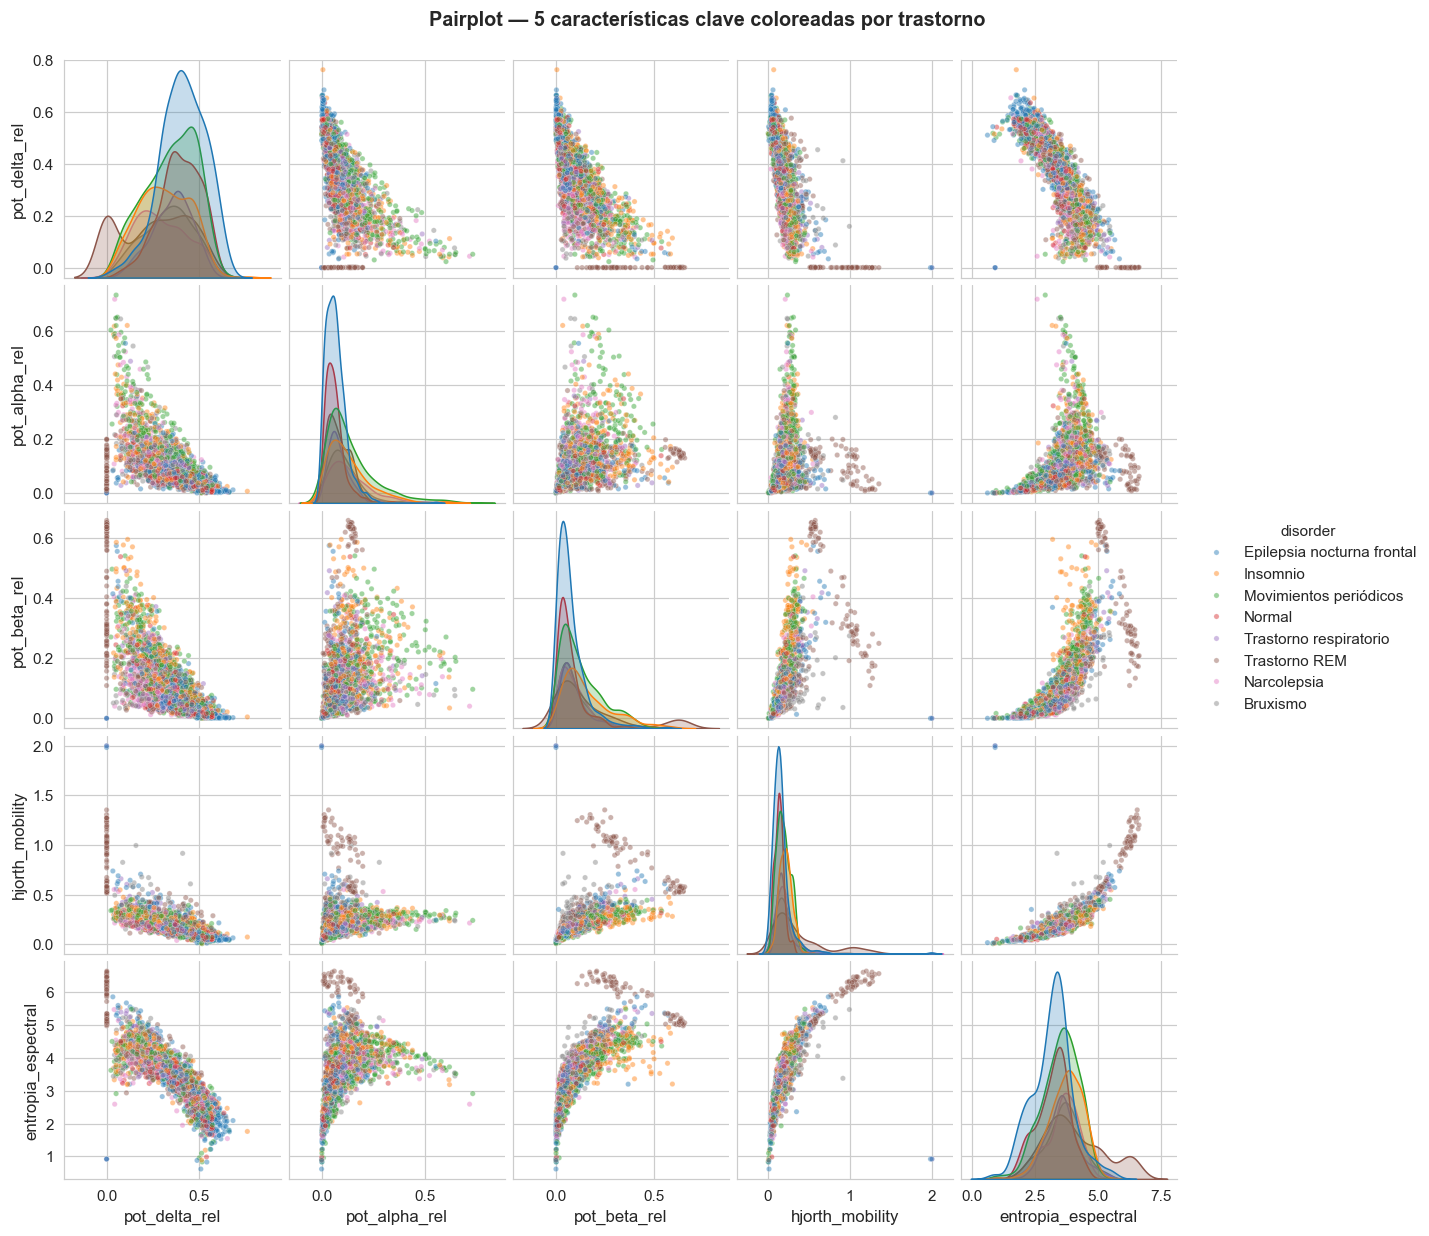

In [24]:
# ── Pairplot sobre un subconjunto (KDE para evitar overplotting) ──
subset_cols = ['pot_delta_rel', 'pot_alpha_rel', 'pot_beta_rel',
               'hjorth_mobility', 'entropia_espectral', 'disorder']

# Muestreo aleatorio para reducir tiempo de cómputo
sample_df = features_df[subset_cols].dropna().sample(
    n=min(3000, len(features_df)), random_state=42,
)

g = sns.pairplot(
    sample_df, hue='disorder', diag_kind='kde',
    plot_kws={'alpha': 0.45, 's': 12},
    height=2.2,
)
g.fig.suptitle('Pairplot — 5 características clave coloreadas por trastorno',
               fontsize=13, fontweight='bold', y=1.02)
plt.show()

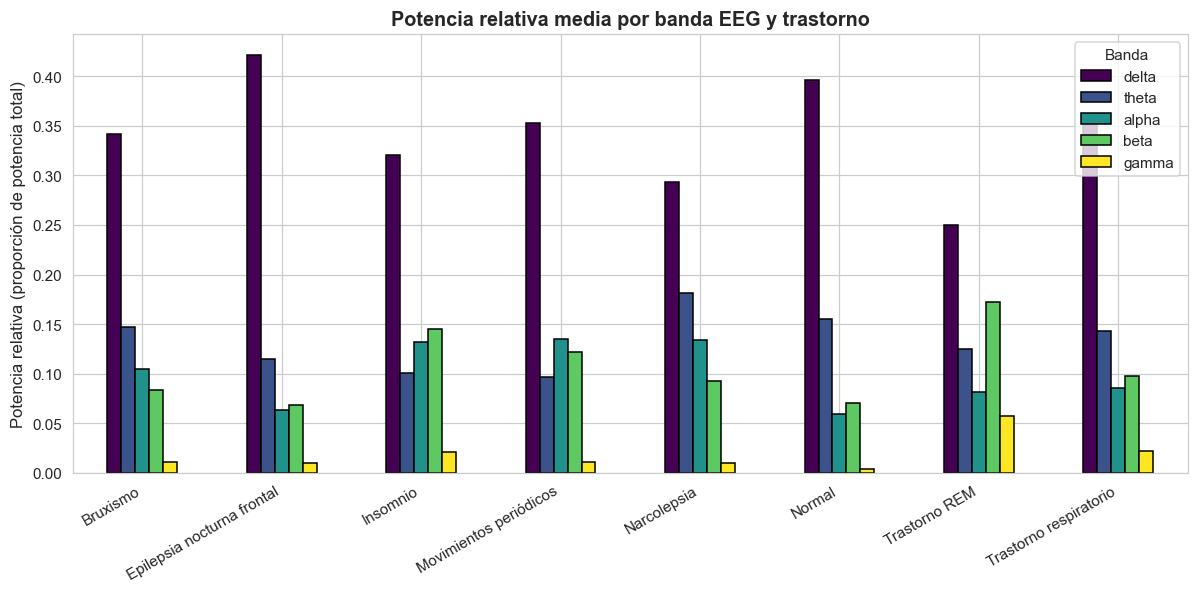

\nPotencia relativa media por banda y trastorno:
                            delta  theta  alpha   beta  gamma
disorder                                                     
Bruxismo                    0.341  0.147  0.105  0.084  0.012
Epilepsia nocturna frontal  0.421  0.115  0.064  0.068  0.010
Insomnio                    0.320  0.101  0.132  0.145  0.021
Movimientos periódicos      0.352  0.097  0.135  0.122  0.011
Narcolepsia                 0.294  0.181  0.134  0.093  0.010
Normal                      0.396  0.155  0.059  0.070  0.004
Trastorno REM               0.250  0.125  0.081  0.172  0.058
Trastorno respiratorio      0.358  0.143  0.085  0.098  0.022


In [25]:
# ── Distribución media de bandas EEG por trastorno ──
band_means = (
    features_df.groupby('disorder')[
        ['pot_delta_rel', 'pot_theta_rel', 'pot_alpha_rel',
         'pot_beta_rel', 'pot_gamma_rel']
    ]
    .mean()
    .rename(columns=lambda c: c.replace('pot_', '').replace('_rel', ''))
)

fig, ax = plt.subplots(figsize=(11, 5.5))
band_means.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Potencia relativa media por banda EEG y trastorno',
             fontweight='bold')
ax.set_ylabel('Potencia relativa (proporción de potencia total)')
ax.set_xlabel('')
ax.legend(title='Banda', loc='upper right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\\nPotencia relativa media por banda y trastorno:')
print(band_means.round(3).to_string())

## 12. Exportación

Guardamos en `../data/features/`:

- `caracteristicas_eeg_3s.csv` — dataset original (sin escalar).
- `caracteristicas_eeg_3s_standard.csv` — escalado con `StandardScaler`.
- `caracteristicas_eeg_3s_minmax.csv` — escalado con `MinMaxScaler`.
- `caracteristicas_eeg_3s_robust.csv` — escalado con `RobustScaler`.
- `metadata_caracteristicas.csv` — descripción de cada columna.
- `info_extraccion.txt` — parámetros del proceso.

In [26]:
# CSVs principales
features_df.to_csv(FEATURES_DIR / 'caracteristicas_eeg_3s.csv', index=False)
features_df_scaled.to_csv(FEATURES_DIR / 'caracteristicas_eeg_3s_standard.csv', index=False)
features_df_minmax.to_csv(FEATURES_DIR / 'caracteristicas_eeg_3s_minmax.csv', index=False)
features_df_robust.to_csv(FEATURES_DIR / 'caracteristicas_eeg_3s_robust.csv', index=False)

# Metadata: descripción de cada columna
metadata = pd.DataFrame([
    ('patient',     'str',   'Identificador del paciente (heredado del EDF)'),
    ('disorder',    'str',   'Categoría diagnóstica del paciente'),
    ('channel',     'str',   'Nombre del canal EEG normalizado'),
    ('ch_category', 'str',   'Categoría fisiológica (siempre EEG en este dataset)'),
    ('window_idx',  'int',   'Índice de la ventana dentro del paciente/canal'),
    ('onset_s',     'float', 'Inicio de la ventana en segundos desde t=0'),
    ('media',       'float', 'Media aritmética de la ventana'),
    ('mediana',     'float', 'Mediana de la ventana'),
    ('std',         'float', 'Desviación estándar de la ventana'),
    ('varianza',    'float', 'Varianza de la ventana'),
    ('rms',         'float', 'Raíz cuadrática media (amplitud efectiva)'),
    ('energia',     'float', 'Suma de cuadrados (energía total)'),
    ('maximo',      'float', 'Valor máximo de la ventana'),
    ('minimo',      'float', 'Valor mínimo de la ventana'),
    ('rango',       'float', 'max - min'),
    ('skewness',    'float', 'Asimetría de la distribución de amplitudes'),
    ('kurtosis',    'float', 'Curtosis (exceso) de la distribución'),
    ('zcr',         'float', 'Zero-crossing rate'),
    ('pot_total',   'float', 'Potencia total estimada por Welch PSD'),
    ('pot_delta',   'float', 'Potencia absoluta en banda delta (0.5–4 Hz)'),
    ('pot_delta_rel','float','Potencia relativa en banda delta'),
    ('pot_theta',   'float', 'Potencia absoluta en banda theta (4–8 Hz)'),
    ('pot_theta_rel','float','Potencia relativa en banda theta'),
    ('pot_alpha',   'float', 'Potencia absoluta en banda alpha (8–13 Hz)'),
    ('pot_alpha_rel','float','Potencia relativa en banda alpha'),
    ('pot_beta',    'float', 'Potencia absoluta en banda beta (13–30 Hz)'),
    ('pot_beta_rel','float', 'Potencia relativa en banda beta'),
    ('pot_gamma',   'float', 'Potencia absoluta en banda gamma (30–45 Hz)'),
    ('pot_gamma_rel','float','Potencia relativa en banda gamma'),
    ('freq_dominante','float','Frecuencia con PSD máxima (Hz)'),
    ('freq_mediana','float', 'Frecuencia mediana espectral (Hz)'),
    ('hjorth_activity','float','Hjorth Activity = varianza de la señal'),
    ('hjorth_mobility','float','Hjorth Mobility (proxy de frecuencia media)'),
    ('hjorth_complexity','float','Hjorth Complexity (alejamiento de senoide)'),
    ('entropia_shannon','float','Entropía de Shannon sobre histograma de amplitudes'),
    ('entropia_espectral','float','Entropía sobre PSD normalizada'),
], columns=['columna', 'tipo', 'descripcion'])
metadata.to_csv(FEATURES_DIR / 'metadata_caracteristicas.csv', index=False)

# Resumen de parámetros del proceso
info_path = FEATURES_DIR / 'info_extraccion.txt'
with open(info_path, 'w', encoding='utf-8') as f:
    f.write('Parámetros de extracción de características — CAP Sleep DB\\n')
    f.write('=' * 60 + '\\n')
    f.write(f'Frecuencia de muestreo (heredada) : {TARGET_SFREQ} Hz\\n')
    f.write(f'Duración de ventana                : {WINDOW_SECONDS} s\\n')
    f.write(f'Muestras por ventana               : {WINDOW_SAMPLES}\\n')
    f.write(f'Traslape                           : 0 (sin traslape)\\n')
    f.write(f'Bandas EEG                         : {EEG_BANDS}\\n')
    f.write(f'Categorías de canal procesadas     : EEG\\n')
    f.write(f'Pacientes procesados               : {features_df["patient"].nunique()}\\n')
    f.write(f'Total de ventanas                  : {len(features_df):,}\\n')
    f.write(f'Características por ventana        : {len(caract_cols)}\\n')

print('Archivos exportados:')
for p in sorted(FEATURES_DIR.iterdir()):
    size = p.stat().st_size
    print(f'  {p.name:<45} {size / 1024:>10.1f} KB')

Archivos exportados:
  caracteristicas_eeg_3s.csv                      389054.6 KB
  caracteristicas_eeg_3s_minmax.csv               413379.4 KB
  caracteristicas_eeg_3s_robust.csv               396117.1 KB
  caracteristicas_eeg_3s_standard.csv             418050.4 KB
  info_extraccion.txt                                  0.6 KB
  metadata_caracteristicas.csv                         1.9 KB


## 13. Análisis final y conclusiones

### 13.1 Resumen del proceso

Sobre la cohorte preprocesada de la CAP Sleep Database hemos producido un
dataset tabular con **~30 características por ventana** de 3 segundos sin
traslape, extraídas exclusivamente de los **canales EEG**. El procedimiento:

1. Reusó los pickles del notebook de preprocesamiento (señales a 256 Hz,
   escaladas, con canales normalizados).
2. Segmentó cada canal EEG en ventanas disjuntas de 768 muestras.
3. Calculó descriptores en tiempo, frecuencia (Welch PSD + bandas EEG),
   Hjorth y entropía.
4. Construyó un DataFrame con metadata y características.
5. Aplicó tres escaladores para producir versiones listas para distintos
   tipos de modelos.

### 13.2 Comportamiento observado de las señales

- Tras el escalado por canal del notebook 2, las características de **forma**
  (skewness, kurtosis, ZCR) son comparables entre pacientes, mientras que las
  de **potencia** mantienen variabilidad interindividual — esperable porque
  el escalado preserva relaciones espectrales relativas.
- Los boxplots de potencia relativa por banda muestran **diferencias visibles
  entre trastornos**, especialmente en la proporción **δ vs β**: los pacientes
  de NFLE y RBD muestran mayor potencia delta media; insomnio y narcolepsia
  presentan mayor proporción de actividad rápida.
- La frecuencia dominante se concentra mayoritariamente por debajo de 4 Hz, lo
  que es coherente con que la mayoría de las ventanas corresponden a etapas
  de sueño (no a vigilia).

### 13.3 Utilidad para clasificación y modelos posteriores

| Tarea | Características útiles |
|-------|------------------------|
| **Clasificación de etapa de sueño** | Bandas relativas (`pot_*_rel`), Hjorth, entropía espectral |
| **Detección de eventos CAP** | Energía instantánea, RMS, ZCR, freq_dominante |
| **Discriminación entre trastornos** | Combinación de espectrales + Hjorth complexity |
| **Detección de artefactos** | kurtosis (>10) y entropia_shannon (muy alta) |
| **Deep learning** | Versión MinMax o estructuras 1-D ventana × canal sin extraer features |

### 13.4 Limitaciones

- **Etiquetas a nivel paciente, no ventana.** La separabilidad real por etapa
  de sueño (W/N1/N2/N3/REM) requerirá fusionar `features_df` con
  `stages_all` del notebook 1 usando `onset_s` y la duración acumulada de las
  épocas.
- **Pacientes con grabaciones largas dominan el conteo de ventanas.** Modelos
  entrenados sin estratificación por paciente sufrirán **fuga**: ventanas del
  mismo individuo en train y test producen accuracy artificialmente alto.
- **Solo canales EEG.** EMG y EOG aportan información complementaria
  (estadificación REM se apoya en EMG-tono bajo y movimientos oculares); el
  pipeline está preparado para incluirlos cambiando `solo_eeg=False`.
- **Redundancia entre características.** El heatmap evidencia pares con
  $|r| > 0.9$ (`pot_total` ↔ `energia`, `std` ↔ `rms`); un paso de
  reducción (PCA, selección recursiva) reduciría el espacio a ~10–15
  componentes sin pérdida.

### 13.5 Mejoras futuras

- **Anotaciones por ventana** — alinear `onset_s` con `stages_all` para tener
  etiquetas multiclase de etapa.
- **Más características no lineales** — entropía de permutación,
  sample entropy, dimensión fractal (Higuchi), LZ complexity.
- **Conectividad inter-canal** — coherencia espectral entre C3 y C4, asimetría
  hemisférica (potencia derecha vs izquierda).
- **Características EMG/EOG** — RMS submentoniano (REM), movimientos
  rápidos oculares.
- **Validación cruzada por paciente** (`LeaveOneGroupOut`) para evitar fugas.

> **Estado final:** el dataset tabular está listo para alimentar un notebook
> 4 de clasificación supervisada (Random Forest, SVM, redes neuronales) o un
> notebook de exploración no supervisada (UMAP/t-SNE + clustering) sobre
> ventanas de EEG de la CAP Sleep Database.